In [11]:
import pandas as pd
from pathlib import Path
from tabulate import tabulate
from PIL import Image
import matplotlib.pyplot as plt


In [12]:
metadata_path = Path('/Users/romitbarua/BreastCancerResearch/Ekyaalo-WSI-ROI-Detection/data/metadata/metadata.csv')

metadata = pd.read_csv(str(metadata_path))

In [13]:
# understand the shape of the dataset & distribution of labels
print("Shape of the dataset:", metadata.shape)
print("\nLabel Distribution:")
label_counts = metadata['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
print(tabulate(label_counts, headers='keys', tablefmt='grid', showindex=False))
print("\nClass Name Distribution (with labels):")
# Count each (class_name, label) pair and present them in a table
class_label_counts = metadata.groupby(['class_name', 'label']).size().reset_index(name='Count')
# To reflect just one label per class if appropriate, you can drop duplicates.
# class_label_counts = metadata[['class_name','label']].drop_duplicates().merge(
#     metadata['class_name'].value_counts().reset_index().rename(columns={'index':'class_name', 'class_name':'Count'}),
#     on='class_name'
# )
print(tabulate(class_label_counts, headers=['Class Name', 'Label', 'Count'], tablefmt='grid', showindex=False))
print("\nLabel Distribution (Percentages):")
label_pct = (metadata['label'].value_counts(normalize=True) * 100).reset_index()
label_pct.columns = ['Label', 'Percentage']
label_pct['Percentage'] = label_pct['Percentage'].round(2)
print(tabulate(label_pct, headers='keys', tablefmt='grid', showindex=False))


Shape of the dataset: (817, 8)

Label Distribution:
+---------+---------+
|   Label |   Count |
+=========+=========+
|       1 |     571 |
+---------+---------+
|       0 |     246 |
+---------+---------+

Class Name Distribution (with labels):
+--------------+---------+---------+
| Class Name   |   Label |   Count |
+==============+=========+=========+
| Benign       |       0 |     246 |
+--------------+---------+---------+
| Malignant    |       1 |     421 |
+--------------+---------+---------+
| Suspicious   |       1 |     150 |
+--------------+---------+---------+

Label Distribution (Percentages):
+---------+--------------+
|   Label |   Percentage |
+=========+==============+
|       1 |        69.89 |
+---------+--------------+
|       0 |        30.11 |
+---------+--------------+


In [14]:
# Check if slides have multiple labels/classes
print("Analyzing slide-level label consistency...\n")

# Group by slide_id and check unique labels and class_names
slide_analysis = metadata.groupby('slide_id').agg({
    'label': ['nunique', lambda x: list(x.unique()), 'count'],
    'class_name': ['nunique', lambda x: list(x.unique())]
}).reset_index()

# Flatten column names
slide_analysis.columns = ['slide_id', 'num_unique_labels', 'unique_labels', 'num_rois', 
                          'num_unique_classes', 'unique_classes']

# Identify slides with multiple labels
slides_with_multiple_labels = slide_analysis[slide_analysis['num_unique_labels'] > 1]
slides_with_multiple_classes = slide_analysis[slide_analysis['num_unique_classes'] > 1]

print("Summary Statistics:")
summary_stats = {
    'Total Slides': [slide_analysis['slide_id'].nunique()],
    'Slides with Multiple Labels': [len(slides_with_multiple_labels)],
    'Slides with Multiple Classes': [len(slides_with_multiple_classes)],
    'Slides with Consistent Labels': [len(slide_analysis[slide_analysis['num_unique_labels'] == 1])],
    'Slides with Consistent Classes': [len(slide_analysis[slide_analysis['num_unique_classes'] == 1])]
}
summary_df = pd.DataFrame(summary_stats).T
summary_df.columns = ['Count']
print(tabulate(summary_df, headers='keys', tablefmt='grid', showindex=True))

if len(slides_with_multiple_labels) > 0:
    print(f"\n⚠️  Found {len(slides_with_multiple_labels)} slide(s) with multiple labels:")
    display_cols = ['slide_id', 'num_unique_labels', 'unique_labels', 'num_unique_classes', 'unique_classes', 'num_rois']
    print(tabulate(slides_with_multiple_labels[display_cols], headers='keys', tablefmt='grid', showindex=False))
else:
    print("\n✓ All slides have consistent labels (each slide has only one label)")

if len(slides_with_multiple_classes) > 0:
    print(f"\n⚠️  Found {len(slides_with_multiple_classes)} slide(s) with multiple class names:")
    display_cols = ['slide_id', 'num_unique_classes', 'unique_classes', 'num_unique_labels', 'unique_labels', 'num_rois']
    print(tabulate(slides_with_multiple_classes[display_cols], headers='keys', tablefmt='grid', showindex=False))
else:
    print("\n✓ All slides have consistent class names (each slide has only one class)")

Analyzing slide-level label consistency...

Summary Statistics:
+--------------------------------+---------+
|                                |   Count |
+================================+=========+
| Total Slides                   |      15 |
+--------------------------------+---------+
| Slides with Multiple Labels    |      12 |
+--------------------------------+---------+
| Slides with Multiple Classes   |      14 |
+--------------------------------+---------+
| Slides with Consistent Labels  |       3 |
+--------------------------------+---------+
| Slides with Consistent Classes |       1 |
+--------------------------------+---------+

⚠️  Found 12 slide(s) with multiple labels:
+--------------+---------------------+----------------------------+----------------------+---------------------------------------+------------+
| slide_id     |   num_unique_labels | unique_labels              |   num_unique_classes | unique_classes                        |   num_rois |
+==============+==

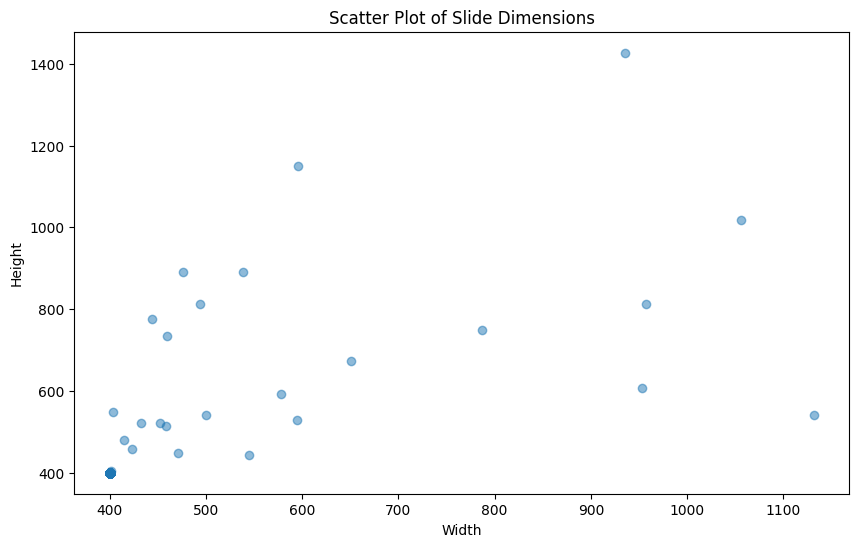

In [15]:
# scatter plot showing the height & width of the slides
plt.figure(figsize=(10, 6))
plt.scatter(metadata['width'], metadata['height'], alpha=0.5)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Scatter Plot of Slide Dimensions')
plt.show()